*** Business Scenario ***
A fintech company provides instant credit limits to customers using a mobile app.
Instead of using complex models, the company wants a similarity-based system that works like:
“Show me customers similar to this new customer, and decide risk accordingly.”
Challenges:
Customers are not easily separable by straight lines
Decisions depend on nearness, not formulas
Feature scale (income vs age) matters a lot
The system must be interactive and explainable
 
•  Load the dataset and explore customer attributes such as:
Age
Income
Loan amount
Credit history
•  Identify which features should be used to measure customer similarity.
 
• Prepare the data so that distance-based comparison is meaningful.
• Explain why preprocessing is necessary for this algorithm.
•  Build a classification model that:
Assigns a customer to High Risk or Low Risk
Makes decisions based on nearest neighbors
•  Train the model using historical customer data.
•  Experiment with different values of K.
 

In [2]:
import numpy as np
import pandas as pd

df=pd.read_csv('credit_risk_dataset.csv')

In [9]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
df[['person_age','person_income','loan_amnt','cb_person_cred_hist_length']].head()

,person_age,person_income,loan_amnt,cb_person_cred_hist_length
0,22,59000,35000,3
1,21,9600,1000,2
2,25,9600,5500,3
3,23,65500,35000,2
4,24,54400,35000,4


In [8]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

X=df[['person_age','person_income','loan_amnt','cb_person_cred_hist_length']]
y=df[['loan_status']]

imputer=SimpleImputer(strategy='median')
X=imputer.fit_transform(X)

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

*** Analyze: ***

What happens when K is very small?
What happens when K is very large?
 
•  Identify the value of K that gives balanced performance.
• Predict risk category for unseen customers.
• Show how the prediction changes when K changes.
•  Evaluate the model using:
Accuracy
Confusion Matrix
•  Analyze:
How many risky customers were correctly identified?
How many safe customers were misclassified?
 

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)  # K=5
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8055853920515574

Confusion Matrix:
 [[4719  376]
 [ 891  531]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.93      0.88      5095
           1       0.59      0.37      0.46      1422

    accuracy                           0.81      6517
   macro avg       0.71      0.65      0.67      6517
weighted avg       0.79      0.81      0.79      6517



c:\Users\RISHITHA SRIJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=300)  # K=5
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

c:\Users\RISHITHA SRIJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy: 0.79729937087617

Confusion Matrix:
 [[5054   41]
 [1280  142]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.99      0.88      5095
           1       0.78      0.10      0.18      1422

    accuracy                           0.80      6517
   macro avg       0.79      0.55      0.53      6517
weighted avg       0.79      0.80      0.73      6517



c:\Users\RISHITHA SRIJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\RISHITHA SRIJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\RISHITHA SRIJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\RISHITHA SRIJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklear

Best K = 19 with accuracy = 0.8232315482584011


c:\Users\RISHITHA SRIJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


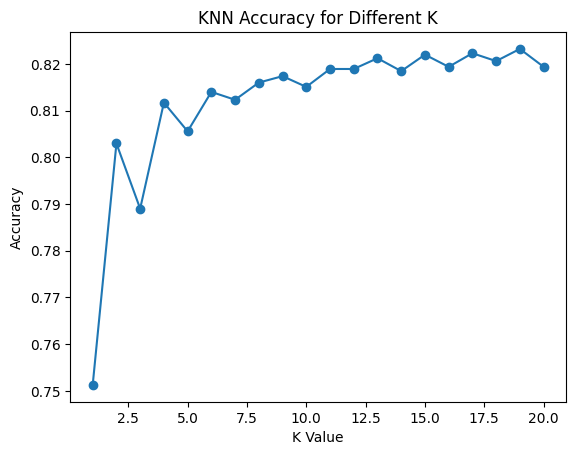

In [14]:
import matplotlib.pyplot as plt

k_values = range(1, 21)
acc_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    pred = knn.predict(x_test)
    acc_scores.append(accuracy_score(y_test, pred))

best_k = k_values[acc_scores.index(max(acc_scores))]
print("Best K =", best_k, "with accuracy =", max(acc_scores))

plt.plot(k_values, acc_scores, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K")
plt.show()


In [17]:
import numpy as np

# Train KNN again with best K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(x_train, y_train)

# Example new customer input
age = float(input("Enter Age: "))
income = float(input("Enter Income: "))
loan_amount = float(input("Enter Loan Amount: "))
credit_hist = float(input("Enter Credit History Length (years): "))

# Create new customer array
new_customer = np.array([[age, income, loan_amount, credit_hist]])
# age=25, income=50k, loan=15k, credit hist=3 yrs

# preprocess new customer
new_customer = imputer.transform(new_customer)
new_customer_scaled = sc.transform(new_customer)

prediction = knn.predict(new_customer_scaled)[0]
print("Predicted Risk:", "High Risk" if prediction==1 else "Low Risk")

# Find nearest neighbors
distances, indices = knn.kneighbors(new_customer_scaled)

print("\nNearest Neighbors (indices in training set):", indices)
print("Distances:", distances)

neighbor_labels = y_train.iloc[indices[0]]
print("\nNeighbor Risk Labels:\n", neighbor_labels.values)


c:\Users\RISHITHA SRIJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Predicted Risk: Low Risk

Nearest Neighbors (indices in training set): [[ 1576 25699 19218 21925  2431 20901  7680  4620 24927 25307 24148 19054
  11521 13095 21692 15084  1407 14472 20945]]
Distances: [[26.21916334 26.21975623 26.21988894 26.21989081 26.2199831  26.22038274
  26.22047264 26.22092763 26.22098825 26.2210622  26.22113435 26.22141208
  26.2232604  26.22500998 26.22517234 26.22519546 26.2252142  26.22552457
  26.22570323]]

Neighbor Risk Labels:
 [[1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]]


c:\Users\RISHITHA SRIJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
